In [1]:
!pip install kagglehub
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("tunguz/online-retail")

print("Path to dataset files:", path)


os.listdir(path)
# df = pd.read_csv("your_file.csv")



Path to dataset files: C:\Users\stanl\.cache\kagglehub\datasets\tunguz\online-retail\versions\1


['Online_Retail.csv']

In [2]:
import os
os.listdir(path)

# Download Dataset from Kaggle
# Download the Online Retail dataset from Kaggle
path = kagglehub.dataset_download("tunguz/online-retail")

# Display the location where the dataset was downloaded
print("Path to dataset files:", path)

# List all files available in the downloaded dataset folder
os.listdir(path)

# Load the Online Retail dataset into a DataFrame
df = pd.read_csv(path + "/Online_Retail.csv", encoding="latin1")

# Display the first 5 rows of the dataset
df.head()


Path to dataset files: C:\Users\stanl\.cache\kagglehub\datasets\tunguz\online-retail\versions\1


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [3]:
# Display the number of rows and columns
df.shape


(541909, 8)

In [4]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Count missing values in each column
# df.isnull().sum()
df.isnull().sum() / len(df) * 100



InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [6]:
df = df.dropna(subset=["Description"])

# Calculate revenue for each transaction, added new column Revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34


In [7]:
df = df.dropna(subset=["CustomerID"])

df.head()
df.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

In [8]:
# Convert InvoiceDate from text to datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

C:\Users\stanl\AppData\Local\Temp\ipykernel_34180\3182951678.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
 8   Revenue      406829 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.0+ MB


In [9]:
# Count duplicate rows
df.duplicated().sum()




np.int64(5225)

In [10]:
# Remove duplicate rows
df = df.drop_duplicates()
# Confirm duplicates were removed
df.duplicated().sum()

np.int64(0)

In [11]:
# Create Year column from InvoiceDate
df["Year"] = df["InvoiceDate"].dt.year
# Create Month column from InvoiceDate
df["Month"] = df["InvoiceDate"].dt.month
# Create Day column from InvoiceDate
df["Day"] = df["InvoiceDate"].dt.day

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1


In [12]:
# Save cleaned dataset
# Feature Engineering
# Created Year, Month, and Day columns from InvoiceDate
# Created Revenue column by multiplying Quantity and UnitPrice
# These new features will be used for trend analysis and dashboard visualizations.
df.to_csv("cleaned_online_retail.csv", index=False)

In [13]:
# Step 3: Exploratory Data Analysis (EDA)
#This section explores the dataset using descriptive statistics, group analysis, and visualizations to identify trends and business insights.

# Revenue Statistics
# Display summary statistics for Revenue
df["Revenue"].describe()

count    401604.000000
mean         20.613638
std         430.352218
min     -168469.600000
25%           4.250000
50%          11.700000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [14]:
# Mean, Median, Min, Max
# Calculate basic statistics for Revenue

print("Mean Revenue:", df["Revenue"].mean())
print("Median Revenue:", df["Revenue"].median())
print("Minimum Revenue:", df["Revenue"].min())
print("Maximum Revenue:", df["Revenue"].max())

Mean Revenue: 20.613637872132752
Median Revenue: 11.7
Minimum Revenue: -168469.6
Maximum Revenue: 168469.6


In [15]:
# Display summary statistics for Quantity

df["Quantity"].describe()

count    401604.000000
mean         12.183273
std         250.283037
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [16]:
# Step 3.2 — Group Analysis Revenue by Country
# Calculate total revenue by country

revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

revenue_by_country.head(10)

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

In [17]:
# Calculate total revenue by month

monthly_revenue = df.groupby("Month")["Revenue"].sum().sort_values(ascending=False)

monthly_revenue


Month
11    1126815.070
10     973306.380
9      929356.232
12     893912.290
5      647011.670
8      615078.090
6      606862.520
3      578576.210
7      573112.321
1      473731.900
2      435534.070
4      425222.671
Name: Revenue, dtype: float64

In [18]:
# Top Products by Revenue
# Calculate revenue by product description

top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)

top_products.head(10)

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Revenue, dtype: float64

Text(0, 0.5, 'Product')

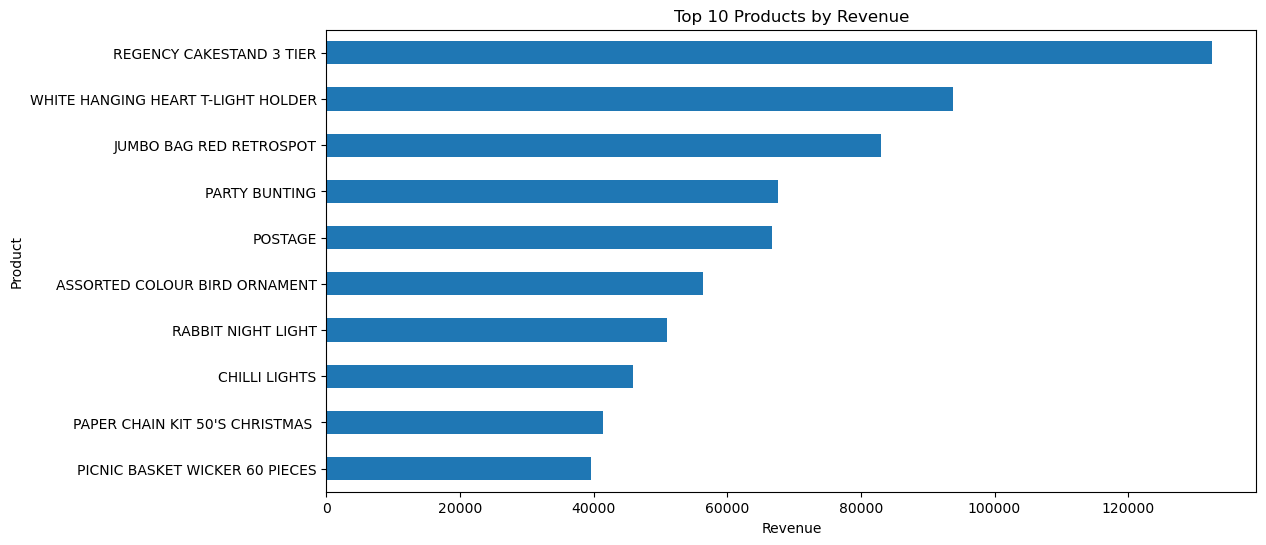

In [19]:
# Import visualization libraries
import matplotlib.pyplot as plt

# Select top 10 products by revenue
top10_products = top_products.head(10)

# Create bar chart
plt.figure(figsize=(12,6))

top10_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

In [20]:
# Question 2: What Time Period Shows Peak Performance?
monthly_revenue.sort_values(ascending=False).head()

Month
11    1126815.070
10     973306.380
9      929356.232
12     893912.290
5      647011.670
Name: Revenue, dtype: float64

In [21]:
# Question 1: Which Product Generates the Highest Revenue?
# Product with highest revenue
top_products.head(1)


Description
REGENCY CAKESTAND 3 TIER    132567.7
Name: Revenue, dtype: float64

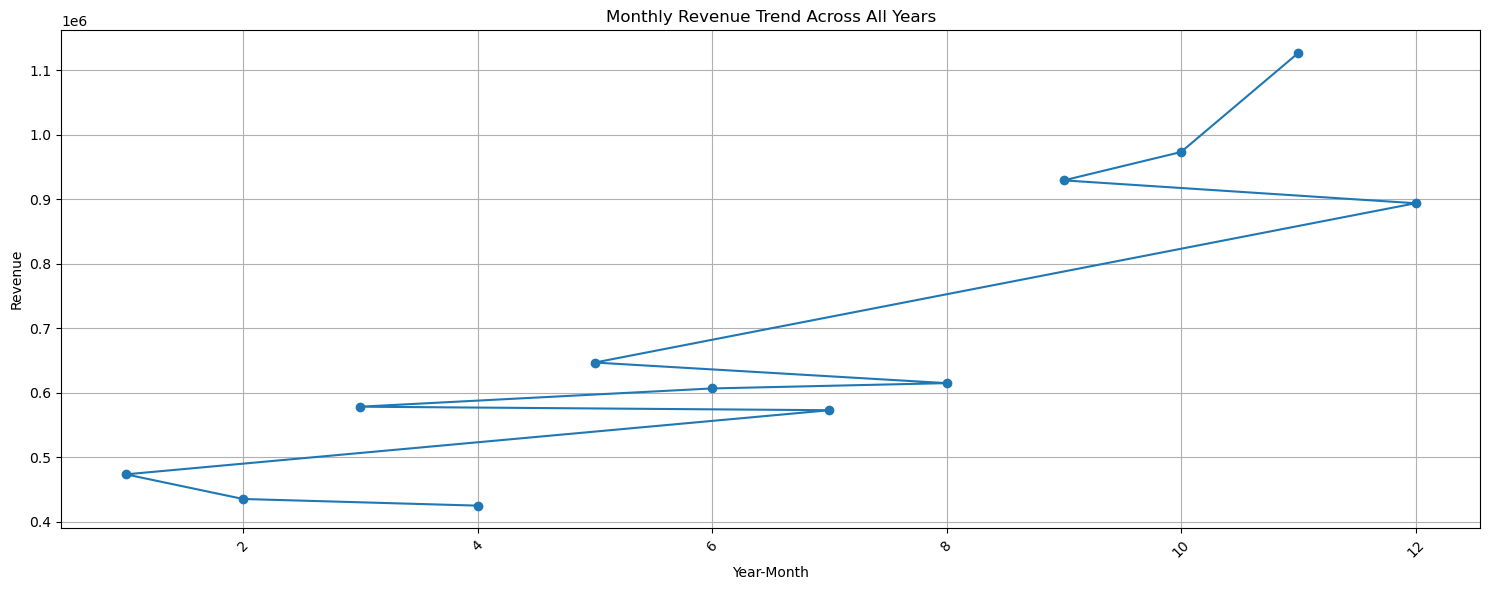

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

monthly_revenue.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue Trend Across All Years")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

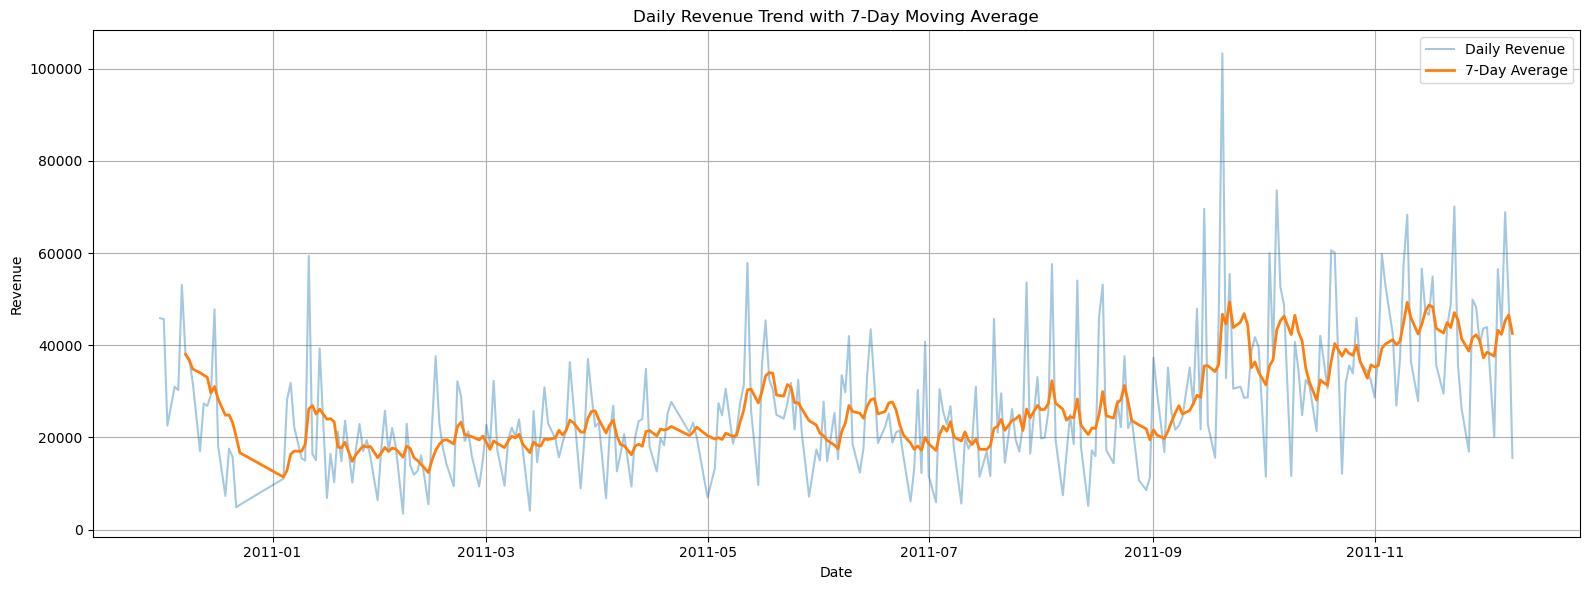

In [23]:
# Create a Date column (remove the time portion)
df["Date"] = df["InvoiceDate"].dt.date

# Calculate total revenue for each day
daily_revenue = df.groupby("Date")["Revenue"].sum()

daily_revenue.head()

# 7-day moving average
daily_revenue_ma = daily_revenue.rolling(window=7).mean()

plt.figure(figsize=(16,6))

plt.plot(daily_revenue.index, daily_revenue.values, alpha=0.4, label="Daily Revenue")
plt.plot(daily_revenue_ma.index, daily_revenue_ma.values,
         linewidth=2, label="7-Day Average")

plt.title("Daily Revenue Trend with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

Top Product: REGENCY CAKESTAND 3 TIER


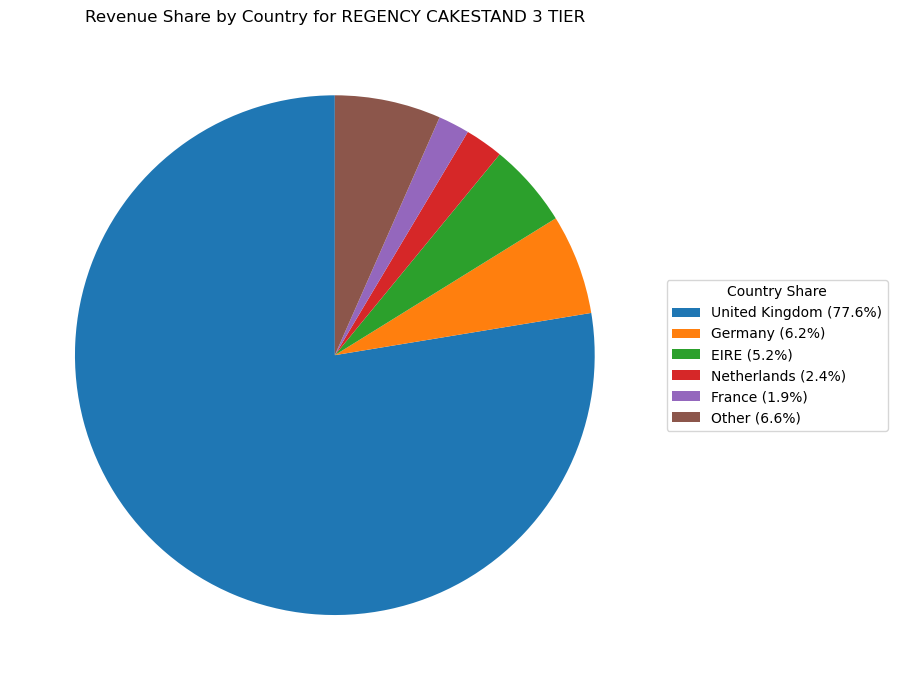

In [24]:
# Find the highest revenue product
top_product = df.groupby("Description")["Revenue"].sum().idxmax()

print("Top Product:", top_product)

# Keep only the top product
top_product_df = df[df["Description"] == top_product]

# Revenue by country for the top product
country_share = (
    top_product_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
# Top 5 countries + Other
top5 = country_share.head(5)
other = country_share.iloc[5:].sum()

country_share_clean = pd.concat([
    top5,
    pd.Series({"Other": other})
])

# Calculate percentages
percentages = (
    country_share_clean / country_share_clean.sum() * 100
).round(1)

# Create legend labels with percentages
legend_labels = [
    f"{country} ({pct}%)"
    for country, pct in zip(country_share_clean.index, percentages)
]

plt.figure(figsize=(10, 7))
wedges, texts = plt.pie(
    country_share_clean,
    startangle=90
)

plt.title(f"Revenue Share by Country for {top_product}")
plt.legend(
    wedges,
    legend_labels,
    title="Country Share",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

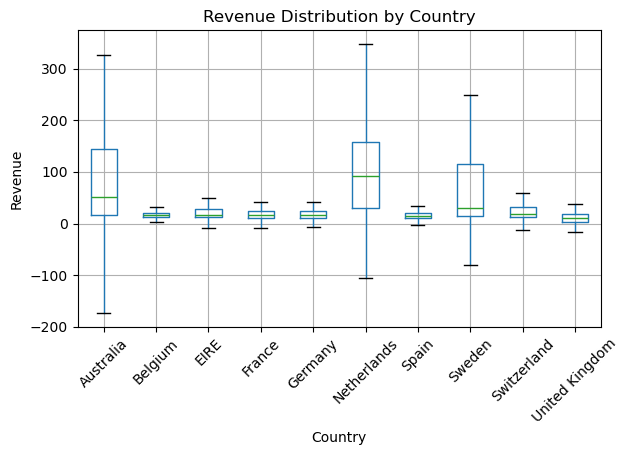

In [25]:
# Top 10 countries by revenue
top_countries = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)
# Filter data
top_country_df = df[df["Country"].isin(top_countries)]

plt.figure(figsize=(12,6))

top_country_df.boxplot(
    column="Revenue",
    by="Country",
    rot=45,
    showfliers=False
)
plt.title("Revenue Distribution by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [26]:
# Question 3: Are There Any Outliers?

#Based on the box plot:
#Answer:
#The box plot indicates the presence of outliers.
#Some transactions have significantly higher revenue than the majority of transactions.
#This suggests a small number of unusually large purchases.

In [27]:
# Question 4: Which Country Performs Best?
revenue_by_country.head(10)


Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

In [28]:
# Step 4: Build Interactive Dashboard (Final Project)
# Install Dash if needed
!pip install dash -q

# Import dashboard libraries
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd





In [29]:

# Prepare dashboard columns
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Date"] = df["InvoiceDate"].dt.date
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()

# Make sure Revenue exists
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Get top 50 products for product filter
top_product_options = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index
)

# Correct month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

available_months = [
    month for month in month_order
    if month in df["MonthName"].unique()
]


In [30]:
# Create Dash app
app = dash.Dash(__name__)

app.layout = html.Div([

    html.H1(
        "Online Retail Sales Dashboard",
        style={
            "textAlign": "center",
            "color": "#003366",
            "marginBottom": "25px"
        }
    ),

    # Filters section
    html.Div([

        html.Div([
            html.Label("Select Month:"),
            dcc.Dropdown(
                id="month_dropdown",
                options=[
                    {"label": month, "value": month}
                    for month in available_months
                ],
                value=None,
                placeholder="All Months",
                clearable=True
            )
        ], style={"width": "30%", "display": "inline-block", "padding": "10px"}),

        html.Div([
            html.Label("Select Country:"),
            dcc.Dropdown(
                id="country_dropdown",
                options=[
                    {"label": country, "value": country}
                    for country in sorted(df["Country"].dropna().unique())
                ],
                value=None,
                placeholder="All Countries",
                clearable=True
            )
        ], style={"width": "30%", "display": "inline-block", "padding": "10px"}),

        html.Div([
            html.Label("Select Product:"),
            dcc.Dropdown(
                id="product_dropdown",
                options=[
                    {"label": product, "value": product}
                    for product in top_product_options
                ],
                value=None,
                placeholder="All Products",
                clearable=True
            )
        ], style={"width": "35%", "display": "inline-block", "padding": "10px"}),

    ], style={"marginBottom": "20px"}),

    # KPI cards
    html.Div([

        html.Div([
            html.H4("Total Revenue"),
            html.H2(id="total_revenue_card")
        ], style={
            "width": "20%",
            "display": "inline-block",
            "textAlign": "center",
            "padding": "20px",
            "backgroundColor": "#f2f2f2",
            "borderRadius": "10px",
            "margin": "10px"
        }),

        html.Div([
            html.H4("Total Orders"),
            html.H2(id="total_orders_card")
        ], style={
            "width": "20%",
            "display": "inline-block",
            "textAlign": "center",
            "padding": "20px",
            "backgroundColor": "#f2f2f2",
            "borderRadius": "10px",
            "margin": "10px"
        }),

        html.Div([
            html.H4("Average Transaction"),
            html.H2(id="avg_transaction_card")
        ], style={
            "width": "20%",
            "display": "inline-block",
            "textAlign": "center",
            "padding": "20px",
            "backgroundColor": "#f2f2f2",
            "borderRadius": "10px",
            "margin": "10px"
        }),

    ], style={"textAlign": "center"}),

    # First row of charts
    html.Div([

        html.Div([
            dcc.Graph(id="bar_chart")
        ], style={
            "width": "49%",
            "display": "inline-block",
            "verticalAlign": "top"
        }),

        html.Div([
            dcc.Graph(id="pie_chart")
        ], style={
            "width": "49%",
            "display": "inline-block",
            "verticalAlign": "top"
        }),

    ]),

    # Second row of charts
    html.Div([

        html.Div([
            dcc.Graph(id="line_chart")
        ], style={
            "width": "49%",
            "display": "inline-block",
            "verticalAlign": "top"
        }),

        html.Div([
            dcc.Graph(id="box_plot")
        ], style={
            "width": "49%",
            "display": "inline-block",
            "verticalAlign": "top"
        }),

    ])

], style={
    "padding": "25px",
    "fontFamily": "Arial"
})

@app.callback(
    [
        Output("total_revenue_card", "children"),
        Output("total_orders_card", "children"),
        Output("avg_transaction_card", "children"),
        Output("bar_chart", "figure"),
        Output("line_chart", "figure"),
        Output("pie_chart", "figure"),
        Output("box_plot", "figure")
    ],
    [
        Input("month_dropdown", "value"),
        Input("country_dropdown", "value"),
        Input("product_dropdown", "value")
    ]
)
def update_dashboard(selected_month, selected_country, selected_product):

    filtered_df = df.copy()

    # Filter by month
    if selected_month:
        filtered_df = filtered_df[filtered_df["MonthName"] == selected_month]

    # Filter by country
    if selected_country:
        filtered_df = filtered_df[filtered_df["Country"] == selected_country]

    # Filter by product
    if selected_product:
        filtered_df = filtered_df[filtered_df["Description"] == selected_product]

    # KPI cards
    total_revenue = filtered_df["Revenue"].sum()
    total_orders = filtered_df["InvoiceNo"].nunique()
    avg_transaction = filtered_df["Revenue"].mean()

    total_revenue_text = f"${total_revenue:,.2f}"
    total_orders_text = f"{total_orders:,}"
    avg_transaction_text = f"${avg_transaction:,.2f}"

    # Bar chart: Top 10 products by revenue
    top_products_dash = (
        filtered_df.groupby("Description")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    fig_bar = px.bar(
        top_products_dash,
        x="Revenue",
        y="Description",
        orientation="h",
        title="<b>Top 10 Products by Revenue</b>"
    )

    fig_bar.update_layout(
        yaxis={"categoryorder": "total ascending"},
        xaxis_title="Revenue",
        yaxis_title="Product",
        height=450
    )

    # Line chart: Daily revenue trend
    daily_revenue_dash = (
        filtered_df.groupby("Date")["Revenue"]
        .sum()
        .reset_index()
    )

    fig_line = px.line(
        daily_revenue_dash,
        x="Date",
        y="Revenue",
        title="<b>Daily Revenue Trend</b>"
    )

    fig_line.update_layout(
        xaxis_title="Date",
        yaxis_title="Revenue",
        height=450
    )

    # Pie chart: Revenue share by country
    country_share_dash = (
        filtered_df.groupby("Country")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(8)
        .reset_index()
    )

    fig_pie = px.pie(
        country_share_dash,
        names="Country",
        values="Revenue",
        title="<b>Revenue Share by Country</b>"
    )

    fig_pie.update_layout(height=450)

    # Box plot: Revenue distribution by top countries
    top_countries = (
        filtered_df.groupby("Country")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    box_df = filtered_df[filtered_df["Country"].isin(top_countries)]

    fig_box = px.box(
        box_df,
        x="Country",
        y="Revenue",
        title="<b>Revenue Distribution by Country</b>",
        points=False
    )

    fig_box.update_layout(
        xaxis_title="Country",
        yaxis_title="Revenue",
        height=450
    )

    return (
        total_revenue_text,
        total_orders_text,
        avg_transaction_text,
        fig_bar,
        fig_line,
        fig_pie,
        fig_box
    )

In [31]:
# Run dashboard in Jupyter
#app.run(jupyter_mode="inline", debug=True)

app.run(jupyter_mode="external", debug=True)

Dash app running on http://127.0.0.1:8050/


In [33]:
df.shape

(401604, 14)